# 线性方程与高斯消元

## 引言
   1. 牛顿法的关键,极其关键的运算,求Hessian 矩阵的逆矩阵,模型有1亿参数  Hessian 矩阵是 1亿 X 1亿?

        Answer: 不会去求逆,而是解一个线性方程

   2. 牛顿法的核心计算过程

        1. 构建线性方程组
        $$
        \boxed{Hp=-g}
        $$

        其中：

        - $H$：Hessian 矩阵（二阶导数矩阵）
        - $g=\nabla f(x_k)$：当前点的梯度向量
        - $p$：牛顿搜索方向

        2. 求解线性方程组

        通过求解：

        $$
        Hp=-g
        $$

        得到搜索方向：

        $$
        p=-H^{-1}g
        $$

        > 注：实际编程中通常使用线性方程组求解器，而不是显式计算逆矩阵。

        3. 更新参数

        得到搜索方向 $p$ 后，更新参数：

        $$
        \boxed{x_{k+1}=x_k+p}
        $$

        代入后得到牛顿法的迭代公式：

        $$
        \boxed{x_{k+1}=x_k-H^{-1}\nabla f(x_k)}
        $$

        4. 完整迭代流程

            1. 初始化参数 $x_0$
            2. 计算梯度 $g=\nabla f(x_k)$
            3. 计算 Hessian 矩阵 $H=\nabla^2 f(x_k)$
            4. 求解线性方程组 $Hp=-g$，得到搜索方向 $p$
            5. 更新参数 $x_{k+1}=x_k+p$
            6. 判断是否满足收敛条件：
                - 未收敛：继续迭代
                - 已收敛：结束

H x = -g  ==> 线性方程组

求解出x ,完成牛顿法的迭代

## 线性代数
   ### 相关历史: 高斯,计算机,<< 九章算术>>
      <<九章算术>> 方程术
      算筹摆成矩阵呢个,"遍乘直除"
      高斯"数学王子"
      数学是科学的皇后,数论是数学的皇后
      计算机时代的矩阵求解
           1. 20世纪,计算机诞生,第一代计算机的主要任务是解线性方程组
   ### 相关问题
   1. 鸡兔同笼  35头,94脚
   2. 电路分析 节点越多,方程组越大,解出电流,电压就可以验证是否可以正常工作
   3. 计算机求解
        - 图形学: 求光线与平面的交点
        - 推荐系统: 矩阵分解求解用户和物品的隐向量
        - 机器学习:线性回归的正规方程
        - 优化算法: 牛顿法中的**H Δ x = -g**
   ### 在数学上直接求逆的代价无法承受
        - A: n Xn 矩阵,O(n^3),需要存储n^2个元素,n =10000,n^2=100000000  内存直接爆炸
        - 高斯消元的复杂度也是O(n^3),无需求逆,方程组做行变换,高斯消元数值稳定,误差更小
                -
   ### 高斯消元,将这种矩阵的算法,**标准化,矩阵化,算法化**
   -例1
            $$
            \begin{cases}
            2x+y-z=8\\
            -3x-y+2z=-11\\
            -2x+y+2z=-3
            \end{cases}
            $$
            简化书写: 常把系数与常熟提取出来
            增广矩阵: $\left[
            \begin{array}{ccc|c}
            2 & 1 & -1 & 8\\
            -3 & -1 & 2 & -11\\
            -2 & 1 & 2 & -3
            \end{array}
            \right]
            $
   - 高斯消元的三大变换
        1. 交换变行
        2. 某一行乘以**非零常数**
        3. 某一行加上另一行的倍数

        目的:把矩阵变成**上三角**矩阵,从**上往下**带回求解
        $$
        \boxed{
        \left[
        \begin{array}{ccc|c}
        1 & 0 & 0 & 2\\
        0 & 1 & 0 & 3\\
        0 & 0 & 1 & -1
        \end{array}
        \right]
        }
        $$
   - 线性方程组求解顺序
        nxn 矩阵A,增广矩阵
        k=1 到 n-1
        1. 选主元,在第k列,找到绝对值最大的元素所在的行,与第k行交换,可以提高数值稳定性
        2. 消元,按你学过的基础消元
     3. 得到上三角矩阵 回代
        解有三种情况 :
        - 唯一解: 矩阵的秩等于未知个数n
        - 无穷多解:矩阵的秩小于n,且出现全零行(0=0)
        - 无解:矩阵的秩小于n,且出现了矛盾行(0=非零)
        矩阵的秩:让我们知道方程组有多少"有用信息"
     高斯消元2.0:LU分解
        如果把我们矩阵分解为A 分解为A=LU
        L是**下三角矩阵(low traingular)**,U是上三角矩阵
        - low traingular: 对角线以上全是0 ,非零元素集中在对角线的下方
        - upper traingular: 对角线以下全是0 ,非零元素集中在对角线的上方
        Ax = b
        1. 解Ly=b(前向带入,很快)
        1. 解Ux = y(回代,很快)
        2. 好处:如果A不变,只有b变了,不需要重新消元,做一次分解,可求解新的b
**解方程组的本质上是找两条直线的交点**
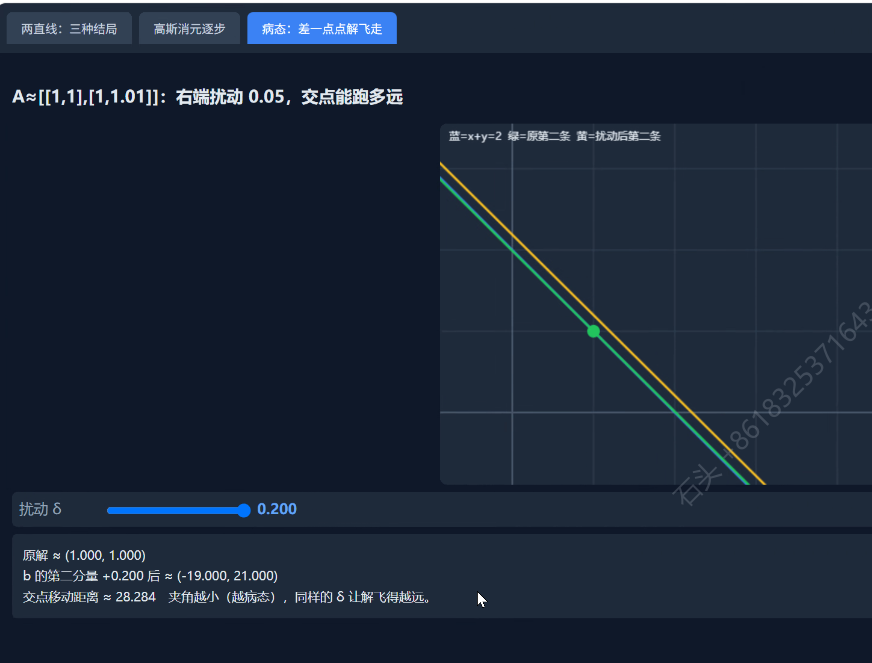
 条件数(condition number)
    - 条件数越大,居正就会越病态,解对误差越敏感
        DL中为什么极度的依赖归一化(Batch Normalization)和正则化(Regularization)
        正则化可以改善矩阵的条件数,让解不会飞走
   1. 永远不要显示的求逆,要高斯消元或者LU分解,同时加上部分组员发,尽量选绝对值大的主元,降低误差放大
   2. 假设矩阵本身就病态,一定要用**正则化(比如岭回归的思想)**,把病态矩阵拉回正常区间
   3. 牛顿法 DL不会使用,Hessian极易病态,导致优化"飞走",所以 Adam 优化被使用

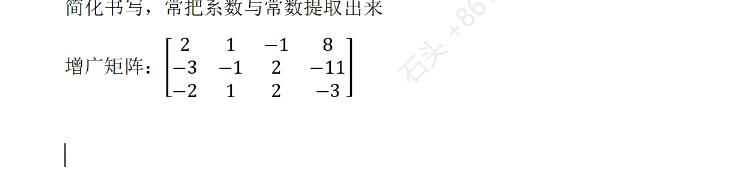

# 线性方程与高斯消元

## 一、引言：为什么需要求解线性方程？

### 1. 牛顿法中的关键运算

牛顿法的关键运算之一是求解一个由 Hessian 矩阵构成的线性方程组。

假设模型有 1 亿个参数，那么 Hessian 矩阵的维度就是：

$$
H \in \mathbb{R}^{10^8 \times 10^8}
$$

这意味着矩阵包含：

$$
10^8 \times 10^8 = 10^{16}
$$

个元素。

如果使用 `float64`，每个元素占 8 字节，那么仅存储这个矩阵就需要约：

$$
10^{16} \times 8 = 8 \times 10^{16}\text{ Bytes}
$$

即约 80 PB 的存储空间。

因此，实际计算中通常不会显式求 Hessian 的逆矩阵，而是将牛顿法转化为求解线性方程组。

### 2. 牛顿法中的线性方程

牛顿法的核心方程：

$$
Hp=-g
$$

其中：

- $H$：Hessian 矩阵，表示目标函数的二阶导数信息。
- $g$：梯度向量，表示目标函数的一阶导数。
- $p$：搜索方向。

如果 $H$ 可逆，在数学上可以写成：

$$
p=-H^{-1}g
$$

但是在实际数值计算中，通常直接求解：

$$
Hp=-g
$$

得到搜索方向 $p$。

然后更新参数：

$$
x_{k+1}=x_k+p
$$

因此，牛顿法中的核心问题可以转化为：

**如何高效、稳定地求解线性方程组？**

---

## 二、线性方程的应用

### 1. 数学历史

中国古代数学著作《九章算术》中已经出现了求解多元线性方程组的方法，称为“方程术”。

当时主要使用算筹进行计算，通过类似现代矩阵行变换的方式求解未知数。

后来，数学家高斯系统化了消元方法，因此现代将相关方法称为高斯消元法。

### 2. 现实应用

线性方程组广泛应用于：

- 鸡兔同笼：根据总头数和总脚数求解鸡和兔的数量。
- 电路分析：根据电压、电流和电阻建立方程。
- 计算机图形学：求解射线与平面的交点。
- 推荐系统：矩阵分解和参数求解。
- 线性回归：通过最小二乘法求解模型参数。
- 机器学习：牛顿法中求解 Hessian 相关的线性方程。

### 3. 计算复杂度

对于一个稠密的 $n \times n$ 矩阵：

| 运算 | 典型复杂度 |
|---|---|
| 存储矩阵 | $O(n^2)$ |
| 高斯消元 | $O(n^3)$ |
| 矩阵求逆 | $O(n^3)$ |

例如，当矩阵维度为 $10000 \times 10000$ 时：

$$
10000^2=10^8
$$

矩阵包含 1 亿个元素。

使用 `float64` 存储时，大约需要：

$$
10^8 \times 8=800000000\text{ Bytes}
$$

约 800 MB 的内存。

这也是为什么在大规模机器学习模型中，需要考虑矩阵的存储和计算成本。

---

## 三、高斯消元法

### 1. 什么是高斯消元？

高斯消元法是一种通过对线性方程组进行初等行变换，将其转化为上三角形式，再通过回代求出未知数的方法。

核心思想：

1. 将线性方程组写成增广矩阵。
2. 通过行变换消去主元下方的元素。
3. 将矩阵转化为上三角矩阵。
4. 使用回代法求解未知数。

### 2. 线性方程组示例

给定方程组：

$$
\begin{cases}
2x+y-z=8\\
-3x-y+2z=-11\\
-2x+y+2z=-3
\end{cases}
$$

将其写成增广矩阵：

$$
\left[
\begin{array}{ccc|c}
2 & 1 & -1 & 8\\
-3 & -1 & 2 & -11\\
-2 & 1 & 2 & -3
\end{array}
\right]
$$

### 3. 初等行变换

高斯消元允许进行以下三种行变换：

- 交换两行。
- 将某一行乘以一个非零常数。
- 将某一行的若干倍加到另一行。

这些操作不会改变原线性方程组的解集。

### 4. 消元过程

原始增广矩阵：

$$
\left[
\begin{array}{ccc|c}
2 & 1 & -1 & 8\\
-3 & -1 & 2 & -11\\
-2 & 1 & 2 & -3
\end{array}
\right]
$$

第一步：消去第一列主元下方的元素。

执行：

$$
R_2 \leftarrow R_2+\frac{3}{2}R_1
$$

$$
R_3 \leftarrow R_3+R_1
$$

得到：

$$
\left[
\begin{array}{ccc|c}
2 & 1 & -1 & 8\\
0 & \frac{1}{2} & \frac{1}{2} & 1\\
0 & 2 & 1 & 5
\end{array}
\right]
$$

第二步：消去第二列主元下方的元素。

执行：

$$
R_3 \leftarrow R_3-4R_2
$$

得到上三角矩阵：

$$
\left[
\begin{array}{ccc|c}
2 & 1 & -1 & 8\\
0 & \frac{1}{2} & \frac{1}{2} & 1\\
0 & 0 & -1 & 1
\end{array}
\right]
$$

### 5. 回代求解

从最后一行开始：

$$
-z=1
$$

因此：

$$
z=-1
$$

代入第二行：

$$
\frac{1}{2}y+\frac{1}{2}z=1
$$

得到：

$$
\frac{1}{2}y-\frac{1}{2}=1
$$

$$
y=3
$$

代入第一行：

$$
2x+y-z=8
$$

$$
2x+3+1=8
$$

$$
x=2
$$

最终解为：

$$
\boxed{
\begin{cases}
x=2\\
y=3\\
z=-1
\end{cases}
}
$$

---

## 四、主元选择与数值稳定性

### 1. 为什么需要选择主元？

在高斯消元过程中，如果当前主元为 0，就无法直接进行除法。

例如：

$$
\begin{bmatrix}
0 & 1\\
2 & 3
\end{bmatrix}
$$

第一列的主元为 0，需要交换两行。

即：

$$
R_1 \leftrightarrow R_2
$$

### 2. 部分主元法

实际数值计算中，通常使用部分主元法：

在当前列尚未消元的行中，选择绝对值最大的元素作为主元，并交换到当前行。

例如：

$$
\begin{bmatrix}
2 & 1\\
-3 & -1
\end{bmatrix}
$$

第一列中：

$$
|-3|>|2|
$$

因此交换两行，将 $-3$ 作为主元。

这样可以减少消元过程中产生过大的中间数值，改善数值稳定性。

---

## 五、线性方程组的解的情况

对于线性方程组：

$$
Ax=b
$$

其中：

- $A$：系数矩阵。
- $x$：未知数向量。
- $b$：常数向量。

增广矩阵为：

$$
[A|b]
$$

根据矩阵的秩，可以判断方程组的解。

### 1. 唯一解

当：

$$
\operatorname{rank}(A)
=
\operatorname{rank}([A|b])
=
n
$$

方程组有唯一解。

其中 $n$ 为未知数的个数。

### 2. 无穷多解

当：

$$
\operatorname{rank}(A)
=
\operatorname{rank}([A|b])
<
n
$$

方程组有无穷多解。

### 3. 无解

当：

$$
\operatorname{rank}(A)
<
\operatorname{rank}([A|b])
$$

方程组无解。

例如消元后出现：

$$
0x+0y+0z=5
$$

即：

$$
0=5
$$

出现矛盾，因此无解。

如果出现：

$$
0x+0y+0z=0
$$

则这一行不产生新的约束，可能存在自由变量。

---

## 六、LU 分解

### 1. 什么是 LU 分解？

LU 分解是将矩阵分解为一个下三角矩阵和一个上三角矩阵的乘积：

$$
A=LU
$$

其中：

- $L$：下三角矩阵。
- $U$：上三角矩阵。

实际计算中，如果需要交换行，通常使用带主元的形式：

$$
PA=LU
$$

其中 $P$ 是置换矩阵。

### 2. 为什么使用 LU 分解？

假设需要求解：

$$
Ax=b
$$

如果已经得到：

$$
A=LU
$$

则：

$$
LUx=b
$$

令：

$$
y=Ux
$$

先求解：

$$
Ly=b
$$

通过前向代入得到 $y$。

然后求解：

$$
Ux=y
$$

通过回代得到 $x$。

### 3. LU 分解的优势

如果系数矩阵 $A$ 不变，但右侧向量 $b$ 发生变化：

$$
Ax=b_1
$$

$$
Ax=b_2
$$

可以重复使用已经得到的 LU 分解，而不必每次重新进行完整的高斯消元。

---

## 七、线性方程的几何意义

### 1. 二元一次方程组

对于两个未知数：

$$
\begin{cases}
a_1x+b_1y=c_1\\
a_2x+b_2y=c_2
\end{cases}
$$

每个方程都表示二维平面中的一条直线。

方程组的解就是两条直线的交点。

### 2. 三种几何情况

- 两条直线相交：唯一解。
- 两条直线重合：无穷多解。
- 两条直线平行且不重合：无解。

对于更高维的线性方程组，也可以从超平面的交集角度理解其解。

---

## 八、条件数与数值稳定性

### 1. 什么是条件数？

条件数用于衡量问题对输入扰动的敏感程度。

对于可逆矩阵 $A$，常用的二范数条件数为：

$$
\kappa(A)=\|A\|_2\|A^{-1}\|_2
$$

条件数越大，通常意味着问题对输入误差越敏感。

### 2. 良态与病态

- 条件数较小：问题通常较为良态。
- 条件数很大：问题可能是病态的。

例如：

$$
A=
\begin{bmatrix}
1 & 0\\
0 & 1000
\end{bmatrix}
$$

其二范数条件数为：

$$
\kappa(A)=1000
$$

当矩阵条件数很大时，输入中的微小误差可能导致求解结果出现较大变化。

### 3. 深度学习中的相关性

深度学习训练中，特征尺度差异可能影响优化过程。

常见处理方式包括：

- 特征标准化。
- 数据归一化。
- 正则化。

例如，岭回归中使用：

$$
(X^TX+\lambda I)w=X^Ty
$$

其中：

- $\lambda$：正则化系数。
- $I$：单位矩阵。

在适当条件下，加入正则化项可以改善矩阵的条件数。

---

## 九、与机器学习优化的联系

### 1. 牛顿法

牛顿法需要求解：

$$
Hp=-g
$$

然后更新：

$$
x_{k+1}=x_k+p
$$

其优势是利用了二阶信息，但完整 Hessian 的存储和计算成本可能非常高。

### 2. 为什么深度学习常用梯度下降？

对于大规模神经网络：

- 参数数量巨大。
- Hessian 矩阵可能非常庞大。
- 求解完整牛顿方向的计算成本较高。
- Hessian 还可能是非正定或病态的。

因此，深度学习中常见的优化方法包括：

- SGD
- Momentum
- Adam

这些方法通常不需要显式构造和求逆完整 Hessian 矩阵。

---

## 十、总结

本节核心知识：

1. 线性方程组是数学、工程和机器学习中的基础计算问题。
2. 牛顿法可以转化为求解线性方程组 $Hp=-g$。
3. 高斯消元通过初等行变换将矩阵转化为上三角形式。
4. 回代法可以从最后一个未知数开始求解。
5. 部分主元法可以改善高斯消元的数值稳定性。
6. 矩阵的秩可以判断线性方程组有唯一解、无穷多解还是无解。
7. LU 分解可以复用矩阵分解结果，求解多个右侧向量对应的方程组。
8. 条件数反映线性系统对输入扰动的敏感程度。
9. 大规模深度学习通常不会显式求解完整 Hessian 的逆矩阵。

